In [ ]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
from dotenv import load_dotenv
import os

load_dotenv()

HOST = os.getenv("HOST")
DATABASE = os.getenv("DATABASE")
USER = os.getenv("USER")
PASSWORD = os.getenv("PASSWORD")
PORT = os.getenv("PORT")

# Bỏ qua cảnh báo của pandas khi dùng psycopg2 trực tiếp với read_sql
warnings.filterwarnings('ignore', category=UserWarning)

try:
    # 1. Kết nối và lấy dữ liệu
    conn = psycopg2.connect(
        host=HOST,
        database=DATABASE,
        user=USER,
        password=PASSWORD,
        port=PORT  # mặc định là 5432
    )
    
    print("Kết nối database thành công!")

    query = """SELECT * FROM "stroke_data";"""
    df = pd.read_sql(query, con=conn)
    print(f"Đã lấy dữ liệu thành công! Kích thước dữ liệu: {df.shape}")

except Exception as e:
    print("Lỗi khi kết nối hoặc lấy dữ liệu:", e)
    df = None # Gán None nếu lỗi để tránh lỗi ở phần sau

finally:
    # Đảm bảo đóng kết nối sau khi lấy xong data
    if 'conn' in locals() and conn:
        conn.close()
        print("Đã đóng kết nối database an toàn.\n")

Kết nối thành công!


C:\Users\OS\AppData\Local\Temp\ipykernel_13296\2768132680.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=conn)


          id  gender   age  hypertension  heart_disease ever_married  \
0      30669    Male   3.0             0              0           No   
1      30468    Male  58.0             1              0          Yes   
2      16523  Female   8.0             0              0           No   
3      56543  Female  70.0             0              0          Yes   
4      46136    Male  14.0             0              0           No   
...      ...     ...   ...           ...            ...          ...   
35099  56196  Female  10.0             0              0           No   
35100   5450  Female  56.0             0              0          Yes   
35101  28375  Female  82.0             1              0          Yes   
35102  27973    Male  40.0             0              0          Yes   
35103  36271  Female  82.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0          children          Rural              95.12  

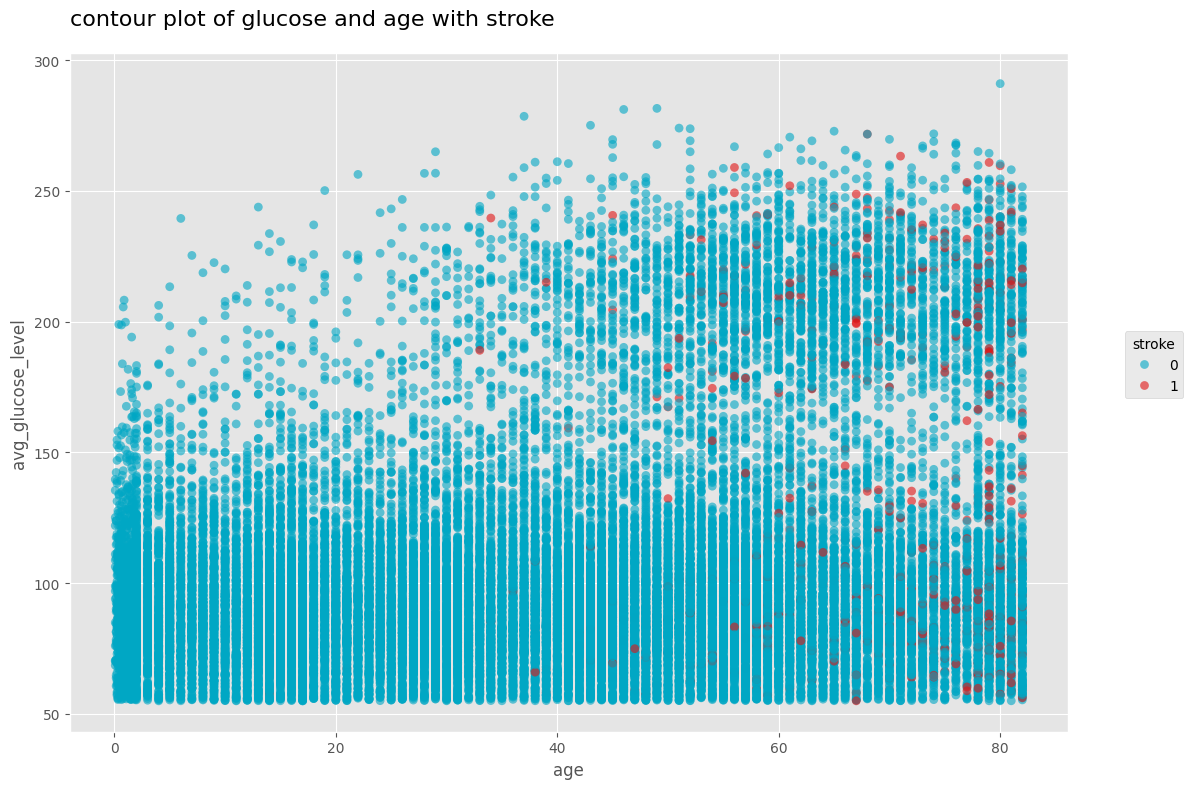

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style giống ggplot2 (nền xám, lưới trắng)
plt.style.use('ggplot')
plt.figure(figsize=(12, 8))

# 1. Vẽ các điểm dữ liệu (Scatter Plot)
# Màu sắc: #F8766D là màu đỏ hồng, #00BFC4 là màu xanh lơ đặc trưng của ggplot2
sns.scatterplot(
    data=df, 
    x='age', 
    y='avg_glucose_level', 
    hue='stroke', 
    palette={0: "#00A7C4", 1: "#E11414"}, 
    alpha=0.6, 
    edgecolor='none',
    s=40
)


# 3. Tùy chỉnh hiển thị
plt.title('contour plot of glucose and age with stroke', fontsize=16, loc='left', pad=20)
plt.xlabel('age', fontsize=12)
plt.ylabel('avg_glucose_level', fontsize=12)

# Chỉnh vị trí legend (chú thích) ra ngoài bên phải nếu cần
plt.legend(title='stroke', bbox_to_anchor=(1.05, 0.6), loc='upper left')

plt.tight_layout()
plt.show()